# <span style="color: #7c3aed; font-weight: 800;">Activations, Forward Propagation & Loss</span>

In today’s notebook, we will be looking at activations, forward propagation, and losses with respect to the Heart Disease Indicator dataset.

We will do the following:
- Understand the need for activation functions.
- Visualize ReLU, Sigmoid and Tanh.
- Pick the right output activation and loss functions for our problem.
- Calculate the forward pass of our mini neural network with NumPy.

## <span style="color: #2563eb; font-weight: 700;">Learning Objectives</span>

- Justify the use of non-linear activation functions.
- Familiarize yourself with ReLU, Sigmoid, Tanh, and Softmax functions.
- Understand forward propagation.
- Choose the correct activation and loss function.
- Conduct a forward pass with NumPy.

## <span style="color: #2563eb; font-weight: 700;">Import Libraries</span>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## <span style="color: #2563eb; font-weight: 700;">Activation Functions</span>

### <span style="color: #0f766e; font-weight: 700;">Importance of Activation Functions</span>

Without activation functions, any neural network will be reduced to a linear model no matter how many layers it has.
The presence of activation functions gives neural networks the ability to learn nonlinear relationships through introducing nonlinearity.
Popular activation functions:
- ReLU for hidden layers
- Sigmoid for binary output classification
- Softmax for multi-class classification
- Tanh for hidden layers

## <span style="color: #2563eb; font-weight: 700;">Common Loss Functions</span>

### <span style="color: #0f766e; font-weight: 700;">Mean Squared Error (MSE)</span>
Used for regression tasks. It measures the average squared difference between
the predicted values and the true values.

### <span style="color: #0f766e; font-weight: 700;">Binary Cross-Entropy</span>
Used for binary classification when the output represents a probability
between 0 and 1.

### <span style="color: #0f766e; font-weight: 700;">Categorical Cross-Entropy</span>
Used for multi-class classification when the output layer uses Softmax
to produce probabilities for multiple classes.

### <span style="color: #0f766e; font-weight: 700;">Activation and Loss Selection Rule</span>

| Task | Output Activation | Loss Function |
|---|---|---|
| Regression | Linear / None | MSE |
| Binary Classification | Sigmoid | Binary Cross-Entropy |
| Multi-Class Classification | Softmax | Categorical Cross-Entropy |



### <span style="color: #0f766e; font-weight: 700;">Why Non-Linearity Is Important</span>

If all layers use only linear operations, stacking multiple layers
still produces a linear function. Therefore, the network cannot learn
complex nonlinear patterns.

Activation functions introduce non-linearity, allowing deep neural
networks to learn more complex relationships.

### <span style="color: #0f766e; font-weight: 700;">Define Functions</span>

In [2]:
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)
def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

### <span style="color: #0f766e; font-weight: 700;">Generate Inputs</span>

In [3]:
x = np.linspace(-5, 5, 500)

#### <span style="color: #ea580c; font-weight: 700;">Plot ReLU</span>

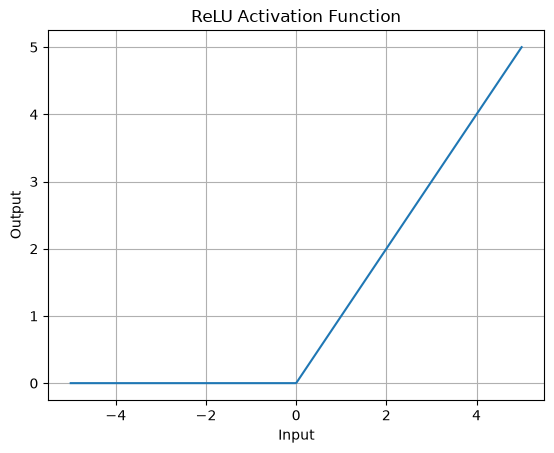

In [4]:
plt.plot(x, relu(x))
plt.title("ReLU Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid()
plt.show()

#### <span style="color: #ea580c; font-weight: 700;">Plot Sigmoid</span>

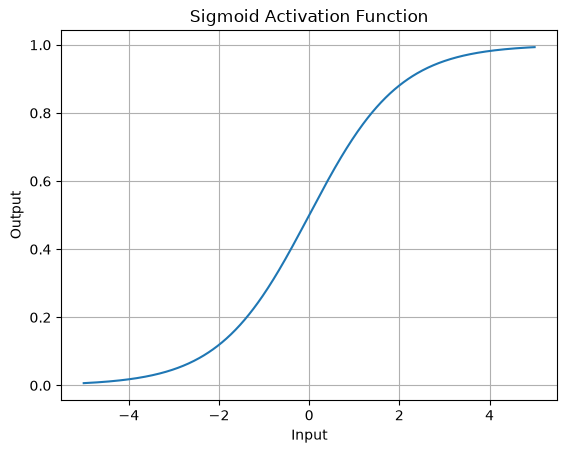

In [5]:
plt.plot(x, sigmoid(x))
plt.title("Sigmoid Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid()
plt.show()

#### <span style="color: #ea580c; font-weight: 700;">Plot Tanh</span>

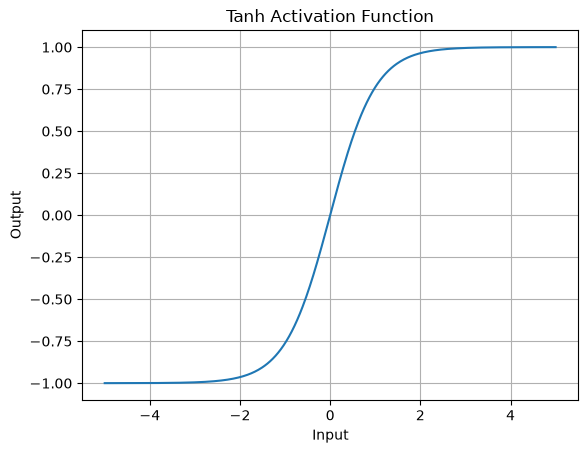

In [6]:
plt.plot(x, tanh(x))
plt.title("Tanh Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid()
plt.show()

## <span style="color: #2563eb; font-weight: 700;">Plots Analysis</span>
- The value of the ReLU function is zero when the input is negative and increases linearly with positive inputs.
- The sigmoid function maps values to [0,1].
- The tanh function maps values to [-1,1].
- ReLU is often used in hidden layers due to its simplicity and efficiency.

### <span style="color: #0f766e; font-weight: 700;">Example of Softmax</span>

In [7]:
softmax_input = np.array([1.0, 2.0, 3.0])
softmax_output = softmax(softmax_input)
print("Softmax Output:")
print(softmax_output)
print("Sum:", np.sum(softmax_output))

Softmax Output:
[0.09003057 0.24472847 0.66524096]
Sum: 0.9999999999999999


### <span style="color: #0f766e; font-weight: 700;">Softmax Analysis</span>

Softmax is mainly used in the output layer for multi-class classification.
It converts raw scores into class probabilities, and all probabilities sum to 1.

## <span style="color: #2563eb; font-weight: 700;">Selection of Output Activation Function and Loss Function</span>

In the Heart Disease Indicator case study, the task falls into the category of binary classification since the class labels in the target variable have two classes only as follows:

- 0 --> No Heart Disease
- 1 --> Heart Disease

Therefore:

- Hidden layers → ReLU
- Output layer → Sigmoid
- Loss function → Binary Cross-Entropy

This loss function will be applied because sigmoid activation function will give probabilities.

## <span style="color: #2563eb; font-weight: 700;">Forward Propagation</span>

Forward propagation is the process of passing inputs through the network to obtain predictions.

Steps:

1. Compute weighted sum:
   
   z = XW + b

2. Apply activation function.

3. Pass outputs to the next layer.

4. Produce final prediction.

### <span style="color: #0f766e; font-weight: 700;">Tiny Neural Network</span>

In [14]:
# Input features
X = np.array([0.8, 0.6])
# Hidden layer weights
W1 = np.array([[0.5, 0.3],[0.2, 0.7]])
b1 = np.array([0.1, 0.2])
# Output layer weights
W2 = np.array([0.6, 0.4])
b2 = 0.1

### <span style="color: #0f766e; font-weight: 700;">Hidden Layer</span>

In [15]:
z1 = np.dot(X, W1) + b1
print("z1:")
print(z1)

z1:
[0.62 0.86]


### <span style="color: #0f766e; font-weight: 700;">ReLU</span>

In [16]:
a1 = relu(z1)
print("a1:")
print(a1)

a1:
[0.62 0.86]


### <span style="color: #0f766e; font-weight: 700;">Output Layer</span>

In [17]:
z2 = np.dot(a1, W2) + b2
print("z2:")
print(z2)

z2:
0.816


## <span style="color: #2563eb; font-weight: 700;">Final Prediction</span>

In [18]:
prediction = sigmoid(z2)
print("Prediction:")
print(prediction)

Prediction:
0.6933865920564957


## <span style="color: #2563eb; font-weight: 700;">Forward Pass Result</span>

The network processed the input through:

Input --> Hidden Layer --> ReLU --> Output Layer --> Sigmoid

The final output is a probability between 0 and 1.

Example:

Prediction = 0.6933865920564957

This means the model estimates an 69% probability of heart disease.

### <span style="color: #0f766e; font-weight: 700;">Loss Function</span>

In [20]:
y_true = 1

loss = -(y_true*np.log(prediction) +(1-y_true)*np.log(1-prediction))

print("Binary Cross Entropy Loss:")
print(loss)

Binary Cross Entropy Loss:
0.36616758243894043


## <span style="color: #2563eb; font-weight: 700;">Loss Analysis</span>

The loss function measures prediction error.

- Small loss --> Good prediction.
- Large loss --> Poor prediction.

Training aims to minimize this loss.

# <span style="color: #7c3aed; font-weight: 800;">Hands-On Lab </span>

### <span style="color: #2563eb; font-weight: 700;">Task 1 —  Plot ReLU, sigmoid, and tanh over a range of inputs to see how each transforms values.</span>

Completed:
- ReLU plotted.
- Sigmoid plotted.
- Tanh plotted.
- Softmax demonstrated.

#### <span style="color: #2563eb; font-weight: 700;">Task 2 — For the Phase 3 project task, decide the correct output activation and loss function, and justify both.</span>

Completed:
- Problem type: Binary Classification
- Output activation: Sigmoid
- Loss function: Binary Cross-Entropy

#### <span style="color: #2563eb; font-weight: 700;">Task 3 — By hand or in NumPy, compute one forward pass for a tiny 2-layer network on a sample input.</span>

Completed:
- Weighted sum calculated for the hidden layer.
- ReLU applied.
- Weighted sum calculated for the output layer.
- Sigmoid applied.
- Final prediction obtained.

#### <span style="color: #2563eb; font-weight: 700;">Task 4 —  Document the choices and the forward-pass result in Markdown</span>

Completed:
- Activation choices justified.
- Forward-pass calculations documented.
- Final prediction and loss reported.

## <span style="color: #2563eb; font-weight: 700;">Day 2 Summary</span>

All required Day 2 tasks were completed. The notebook demonstrates
activation functions, activation selection, forward propagation,
prediction generation, and loss calculation using NumPy.